In [1]:
import sys
import os

# Add the root of the project to the path
this_path = os.path.abspath(os.getcwd())
source_path = os.path.abspath(os.path.join(os.getcwd(), '..', '..'))
sys.path.append(source_path)
output_dir = os.path.join(this_path, 'datasets')
dataset_name = 'icdar' #icdar
split='private' #train, public, private

# init

In [33]:
import pandas as pd

source_file=f'{dataset_name}_{split}_df.csv' 
train_df = pd.read_csv(f"{this_path}\\datasets\\{source_file}")
print(f"Number of unique writers in {split} set: {len(train_df['writer'].unique())}")

modality="patches"
groupby = 'file_name' # 'file_name' for icdar (one page is one filename), 'same_text' for iam (one page is split on multiple 
#files (each a line), same_text is the form index
if dataset_name == 'iam':
    groupby = 'same_text'
    modality="patches_iam"
elif dataset_name == 'icdar':
    groupby = 'file_name'

gw=5
prop=1
n_cc=1
resolution=224
stride=int(resolution/2)
sort_by="black_ratio"
#i select the m patches per file that have the highest number of cc
m = 5
print(train_df.head())


Number of unique writers in private set: 122
   writer  isEng  same_text  \
0     283      0          0   
1     283      0          1   
2     283      1          0   
3     283      1          1   
4     285      0          0   

                                           file_name  male        Usage  
0  C:\Users\andre\PhD\Datasets\ICDAR 2013 - Gende...     1  PrivateTest  
1  C:\Users\andre\PhD\Datasets\ICDAR 2013 - Gende...     1  PrivateTest  
2  C:\Users\andre\PhD\Datasets\ICDAR 2013 - Gende...     1  PrivateTest  
3  C:\Users\andre\PhD\Datasets\ICDAR 2013 - Gende...     1  PrivateTest  
4  C:\Users\andre\PhD\Datasets\ICDAR 2013 - Gende...     0  PrivateTest  


# run

In [ ]:
if modality=="final":
    train_df_expanded = pd.DataFrame(sum(train_df.apply(image_processing.process_row_resolution, axis=1,args=(resolution,stride, n_cc)), []))
elif modality=="body":
    train_df_expanded = pd.DataFrame(sum(train_df.apply(image_processing.process_row_body, axis=1,args=()), []))
elif modality=="patches":
    train_df_expanded = pd.DataFrame(sum(train_df.apply(image_processing.process_row, axis=1,args=(gw, n_cc,prop)), []))
elif modality=="patches_iam":
    train_df_expanded = pd.DataFrame(sum(train_df.apply(image_processing.process_row_iam, axis=1,args=(gw, n_cc,prop)), []))

train_df_expanded.head(10)

,writer,isEng,same_text,file_name,male,Usage,x,y,x2,y2,n_cc,black_ratio
0,283,0,0,C:\Users\andre\PhD\Datasets\ICDAR 2013 - Gende...,1,PrivateTest,0,493,493,986,36,0.024699
0,283,0,0,C:\Users\andre\PhD\Datasets\ICDAR 2013 - Gende...,1,PrivateTest,493,493,986,986,55,0.037396
0,283,0,0,C:\Users\andre\PhD\Datasets\ICDAR 2013 - Gende...,1,PrivateTest,986,493,1479,986,51,0.033203
0,283,0,0,C:\Users\andre\PhD\Datasets\ICDAR 2013 - Gende...,1,PrivateTest,1479,493,1972,986,50,0.038223
0,283,0,0,C:\Users\andre\PhD\Datasets\ICDAR 2013 - Gende...,1,PrivateTest,1972,493,2465,986,33,0.027184
0,283,0,0,C:\Users\andre\PhD\Datasets\ICDAR 2013 - Gende...,1,PrivateTest,0,986,493,1479,47,0.035717
0,283,0,0,C:\Users\andre\PhD\Datasets\ICDAR 2013 - Gende...,1,PrivateTest,493,986,986,1479,58,0.041576
0,283,0,0,C:\Users\andre\PhD\Datasets\ICDAR 2013 - Gende...,1,PrivateTest,986,986,1479,1479,68,0.033273
0,283,0,0,C:\Users\andre\PhD\Datasets\ICDAR 2013 - Gende...,1,PrivateTest,1479,986,1972,1479,63,0.040292
0,283,0,0,C:\Users\andre\PhD\Datasets\ICDAR 2013 - Gende...,1,PrivateTest,1972,986,2465,1479,32,0.022465


In [79]:
train_df_expanded = train_df_expanded.reset_index(drop=True)
train_df_expanded.head(10)

,file_name,writer,male,isEng,same_text,form_id,x,y,x2,y2,n_cc,black_ratio
0,C:\Users\andre\PhD\Datasets\iam online\lineIma...,10018,1,0,1,a01-000x,0,0,609,130,10,0.099962
1,C:\Users\andre\PhD\Datasets\iam online\lineIma...,10018,1,0,1,a01-000x,609,0,1218,130,10,0.107301
2,C:\Users\andre\PhD\Datasets\iam online\lineIma...,10018,1,0,1,a01-000x,1218,0,1827,130,12,0.096716
3,C:\Users\andre\PhD\Datasets\iam online\lineIma...,10018,1,0,1,a01-000x,0,0,636,126,8,0.087526
4,C:\Users\andre\PhD\Datasets\iam online\lineIma...,10018,1,0,1,a01-000x,636,0,1272,126,11,0.101453
5,C:\Users\andre\PhD\Datasets\iam online\lineIma...,10018,1,0,1,a01-000x,1272,0,1908,126,9,0.081911
6,C:\Users\andre\PhD\Datasets\iam online\lineIma...,10018,1,0,1,a01-000x,0,0,651,141,7,0.106111
7,C:\Users\andre\PhD\Datasets\iam online\lineIma...,10018,1,0,1,a01-000x,651,0,1302,141,8,0.075410
8,C:\Users\andre\PhD\Datasets\iam online\lineIma...,10018,1,0,1,a01-000x,1302,0,1953,141,10,0.086926
9,C:\Users\andre\PhD\Datasets\iam online\lineIma...,10018,1,0,1,a01-000x,0,0,624,120,8,0.094738


In [80]:
train_df_expanded_sorted = train_df_expanded.sort_values(by=sort_by, ascending=False)
train_df_expanded = train_df_expanded_sorted.groupby(groupby).head(m)   # Select top m patches per page

# Visual check

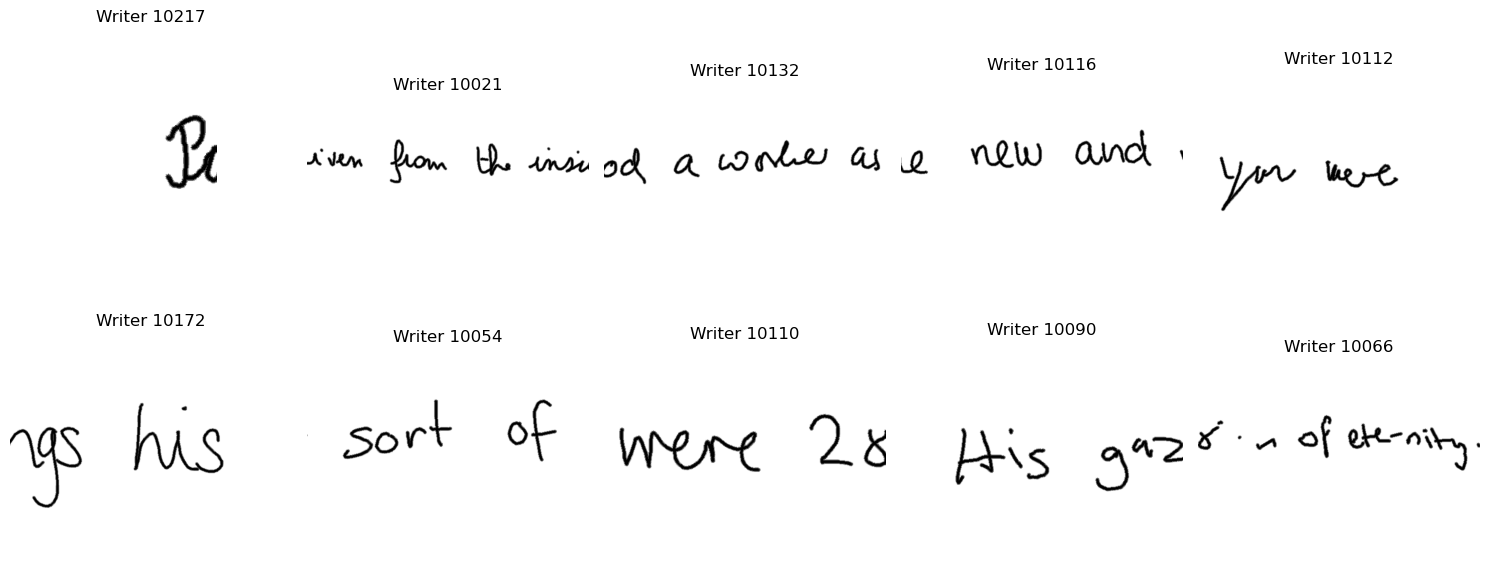

In [66]:
visualization.plot_cropped_sections(train_df_expanded)

In [ ]:
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import numpy as np
from PIL import Image


def show_patches(df, top_n=5, path_col="file_name",
                 x="x", y="y", x2="x2", y2="y2", score="n_cc",
                 image=None, ax=None, label_scores=True):
    """
    Draw all patches of one image and highlight the `top_n` rows with the
    highest `score` (n_cc).

    df    : rows belonging to ONE image (all sharing the same path)
    image : optional pre-loaded array/PIL image; otherwise read from path_col
    """
    if image is None:
        image = Image.open(df[path_col].iloc[0])
    img = np.asarray(image)

    if ax is None:
        h, w = img.shape[:2]
        fig, ax = plt.subplots(figsize=(min(20, w / 60), max(2, h / 60)))

    ax.imshow(img, cmap="gray" if img.ndim == 2 else None)
    ax.set_axis_off()

    # indices of the N best rows
    best = set(df[score].nlargest(top_n).index)
    print(len(df),len(df[score].nlargest(top_n)),best)

    for idx, r in df.iterrows():
        x0, y0 = r[x], r[y]
        w, h = r[x2] - r[x], r[y2] - r[y]
        hot = idx in best
        ax.add_patch(mpatches.Rectangle(
            (x0, y0), w, h,
            fill=False,
            edgecolor="red" if hot else "deepskyblue",
            linewidth=2.5 if hot else 0.5,
            zorder=3 if hot else 2,
        ))
        if label_scores:
            ax.text(x0 + 3, y0 + 14, f"{r[score]}",
                    color="red" if hot else "deepskyblue",
                    fontsize=9, weight="bold" if hot else "normal", zorder=4)

    ax.set_title(f"{len(df)} patches — top {top_n} by {score} in red")
    return ax
#check that file_name has only one unique value
unique_files = train_df_expanded['file_name'].unique()
if len(unique_files) != 1:
    print(f"Warning: train_df_expanded has {len(unique_files)} unique file_name values. Expected 1.")
train_df_expanded.reset_index(drop=True, inplace=True)
show_patches(train_df_expanded, top_n=m, score="n_cc")

# tests

In [24]:
tests.check_occurrences(train_df_expanded,count=m)

Some writers do not occur exactly 40 times.
writer
10017    354
10006    267
10007    237
10212    231
10145    210
10211    210
10137    207
10188    204
10033    195
10084    195
10128    192
10060    186
10130    183
10038    183
10048    183
10120    183
10171    177
10068    177
10187    174
10122    168
10152    162
10133    162
10195    159
10045    159
10193    156
10196    153
10158    152
10083    150
10203    150
10149    144
10185    144
10202    141
10070    138
10078    129
Name: count, dtype: int64


# save

In [81]:
train_df_expanded['index']=train_df_expanded.index
train_df_expanded.head(10)

,file_name,writer,male,isEng,same_text,form_id,x,y,x2,y2,n_cc,black_ratio,index
4173,C:\Users\andre\PhD\Datasets\iam online\lineIma...,10018,1,0,827,g04-081,176,0,264,84,5,0.214150,4173
4171,C:\Users\andre\PhD\Datasets\iam online\lineIma...,10018,1,0,827,g04-081,0,0,88,84,3,0.202110,4171
4162,C:\Users\andre\PhD\Datasets\iam online\lineIma...,10018,1,0,827,g04-081,0,0,105,77,3,0.185405,4162
4164,C:\Users\andre\PhD\Datasets\iam online\lineIma...,10018,1,0,827,g04-081,210,0,315,77,3,0.176623,4164
570,C:\Users\andre\PhD\Datasets\iam online\lineIma...,10006,0,0,129,a06-152,0,0,424,82,12,0.163656,570
569,C:\Users\andre\PhD\Datasets\iam online\lineIma...,10006,0,0,129,a06-152,878,0,1317,81,8,0.161984,569
567,C:\Users\andre\PhD\Datasets\iam online\lineIma...,10006,0,0,129,a06-152,0,0,439,81,11,0.159200,567
1317,C:\Users\andre\PhD\Datasets\iam online\lineIma...,10006,0,0,274,b06-042,1020,0,1530,88,8,0.158534,1317
4172,C:\Users\andre\PhD\Datasets\iam online\lineIma...,10018,1,0,827,g04-081,88,0,176,84,2,0.156250,4172
580,C:\Users\andre\PhD\Datasets\iam online\lineIma...,10006,0,0,129,a06-152,379,0,758,94,8,0.152361,580


In [82]:
prefix=os.path.splitext(source_file)[0]
output_file = os.path.join(output_dir, f"{prefix}_w_patches.csv")
train_df_expanded.to_csv(output_file, index=False)

print(f"Dataframe saved to {output_file}")
print(len(train_df_expanded))
print(f"Number of unique writers in {split} set: {len(train_df_expanded['writer'].unique())}")

Dataframe saved to c:\Users\andre\VsCode\PD related projects\gender_detection\notebooks\pipeline_single_model\datasets\iam_private_df_w_patches.csv
9293
Number of unique writers in private set: 53


In [83]:
df = pd.read_csv(os.path.join(output_dir, 'iam_private_df_w_patches.csv'))
print(df[df['file_name']=='C:\\Users\\andre\\PhD\\Datasets\\iam online\\lineImages-all\\lineImages\\g04\\g04-081\\g04-081-01.tif'])


                                             file_name  writer  male  isEng  \
2    C:\Users\andre\PhD\Datasets\iam online\lineIma...   10018     1      0   
3    C:\Users\andre\PhD\Datasets\iam online\lineIma...   10018     1      0   
281  C:\Users\andre\PhD\Datasets\iam online\lineIma...   10018     1      0   

     same_text  form_id    x  y   x2  y2  n_cc  black_ratio  index  
2          827  g04-081    0  0  105  77     3     0.185405   4162  
3          827  g04-081  210  0  315  77     3     0.176623   4164  
281        827  g04-081  105  0  210  77     2     0.089920   4163  


# easy access

In [5]:
def reload_modules():
    import importlib
    import utils.image_processing as image_processing
    import utils.file_IO as file_IO
    import utils.visualization as visualization
    import utils.tests as tests

    importlib.reload(file_IO)
    importlib.reload(image_processing)
    importlib.reload(visualization)
    importlib.reload(tests)

    return image_processing, file_IO, visualization, tests
image_processing, file_IO, visualization, tests = reload_modules()